In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

In [ ]:
# Training Data

X = np.array([
    [1, 3],
    [4, 10]
], dtype=float)

y = np.array([5, 6], dtype=float)

# Initial parameters
m1 = -1.0
m2 = 2.0
b = 1.0

learning_rate = 0.01
iterations = 3

print("Initial Parameters")
print("m1 =", m1)
print("m2 =", m2)
print("b =", b)

Initial Parameters
m1 = -1.0
m2 = 2.0
b = 1.0


In [ ]:
# Prediction Function

def predict(m1, m2, b):
    return m1 * X[:,0] + m2 * X[:,1] + b

# Mean Squared Error

def mse(m1, m2, b):

    predictions = predict(m1, m2, b)

    errors = predictions - y

    return np.mean(errors ** 2)

In [ ]:
# Derivative Functions

def grad_m1(value):
    return mse(value[0], m2, b)

def grad_m2(value):
    return mse(m1, value[0], b)

def grad_b(value):
    return mse(m1, m2, value[0])

In [ ]:
m1_history = []
m2_history = []
b_history = []
error_history = []

for i in range(iterations):

    print("\n==============================")
    print("Iteration", i + 1)

    # Predictions

    predictions = predict(m1, m2, b)

    print("Predictions =", predictions)

    # Errors

    errors = predictions - y

    print("Errors =", errors)

    # Cost

    cost = mse(m1, m2, b)

    print("MSE =", cost)

    # Gradients using SciPy

    gradient_m1 = approx_fprime(
        np.array([m1]),
        grad_m1,
        epsilon=1e-6
    )[0]

    gradient_m2 = approx_fprime(
        np.array([m2]),
        grad_m2,
        epsilon=1e-6
    )[0]

    gradient_b = approx_fprime(
        np.array([b]),
        grad_b,
        epsilon=1e-6
    )[0]

    print("Gradient m1 =", gradient_m1)
    print("Gradient m2 =", gradient_m2)
    print("Gradient b =", gradient_b)

    # Update Parameters

    m1 = m1 - learning_rate * gradient_m1

    m2 = m2 - learning_rate * gradient_m2

    b = b - learning_rate * gradient_b

    print("Updated m1 =", m1)
    print("Updated m2 =", m2)
    print("Updated b =", b)

    m1_history.append(m1)
    m2_history.append(m2)
    b_history.append(b)
    error_history.append(cost)


Iteration 1
Predictions = [ 6. 17.]
Errors = [ 1. 11.]
MSE = 61.0
Gradient m1 = 45.0000085039753
Gradient m2 = 113.00005451727957
Gradient b = 12.000001015187934
Updated m1 = -1.450000085039753
Updated m2 = 0.8699994548272043
Updated b = 0.8799999898481207

Iteration 2
Predictions = [2.03999827 3.7799942 ]
Errors = [-2.96000173 -2.2200058 ]
MSE = 6.84501800344623
Gradient m1 = -11.840016438477248
Gradient m2 = -31.08000871065442
Gradient b = -5.180006532008267
Updated m1 = -1.3315999206549805
Updated m2 = 1.1807995419337485
Updated b = 0.9318000551682033

Iteration 3
Predictions = [3.14259876 7.41339579]
Errors = [-1.85740124  1.41339579]
MSE = 2.72381351485287
Gradient m1 = 3.7961904280973067
Gradient m2 = 8.5618087000521
Gradient b = -0.44400444786207854
Updated m1 = -1.3695618249359536
Updated m2 = 1.0951814549332275
Updated b = 0.9362400996468241


In [ ]:
print("\n==============================")
print("Final Parameters")

print("m1 =", m1)
print("m2 =", m2)
print("b =", b)

final_predictions = predict(m1, m2, b)

print("\nFinal Predictions")

print(final_predictions)


Final Parameters
m1 = -1.3695618249359536
m2 = 1.0951814549332275
b = 0.9362400996468241

Final Predictions
[2.85222264 6.40980735]


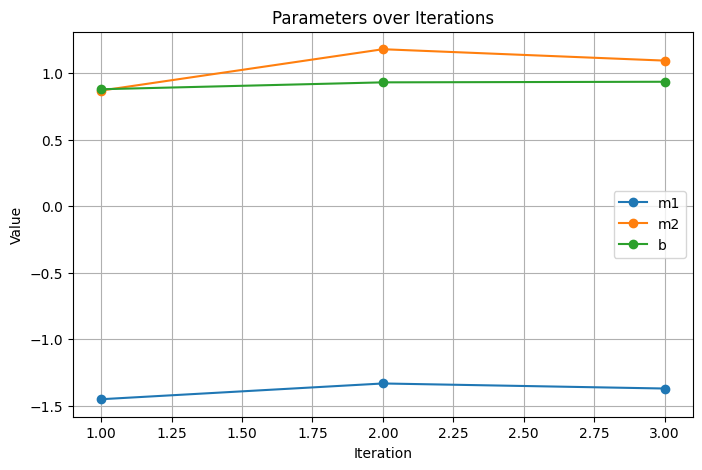

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,iterations+1),m1_history,marker='o',label='m1')

plt.plot(range(1,iterations+1),m2_history,marker='o',label='m2')

plt.plot(range(1,iterations+1),b_history,marker='o',label='b')

plt.title("Parameters over Iterations")

plt.xlabel("Iteration")

plt.ylabel("Value")

plt.grid(True)

plt.legend()

plt.show()

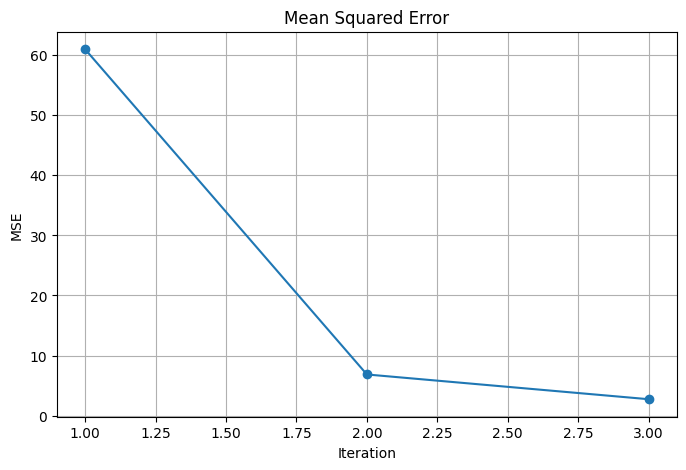

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,iterations+1),error_history,marker='o')

plt.title("Mean Squared Error")

plt.xlabel("Iteration")

plt.ylabel("MSE")

plt.grid(True)

plt.show()